In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import io
import os

In [ ]:
whiteouts = pd.read_csv('white_out_plays.csv')
penn_games = pd.read_csv('penn_state_plays.csv')
oregon_games = pd.read_csv('oregon_games_data.csv')
plays = pd.read_csv('p4_p4_plays.csv')



C:\Users\bchm5\AppData\Local\Temp\ipykernel_8700\3286598725.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  plays = pd.read_csv('p4_p4_plays.csv')


         expected_points_added        gain_loss       touchdown        \
                          mean count       mean count      mean count   
pressure                                                                
0                     0.191676    68   5.733333    60  0.044118    68   
1                     0.143300    10  10.000000     8  0.100000    10   

         first_down_gained        
                      mean count  
pressure                          
0                 0.294118    68  
1                 0.200000    10  


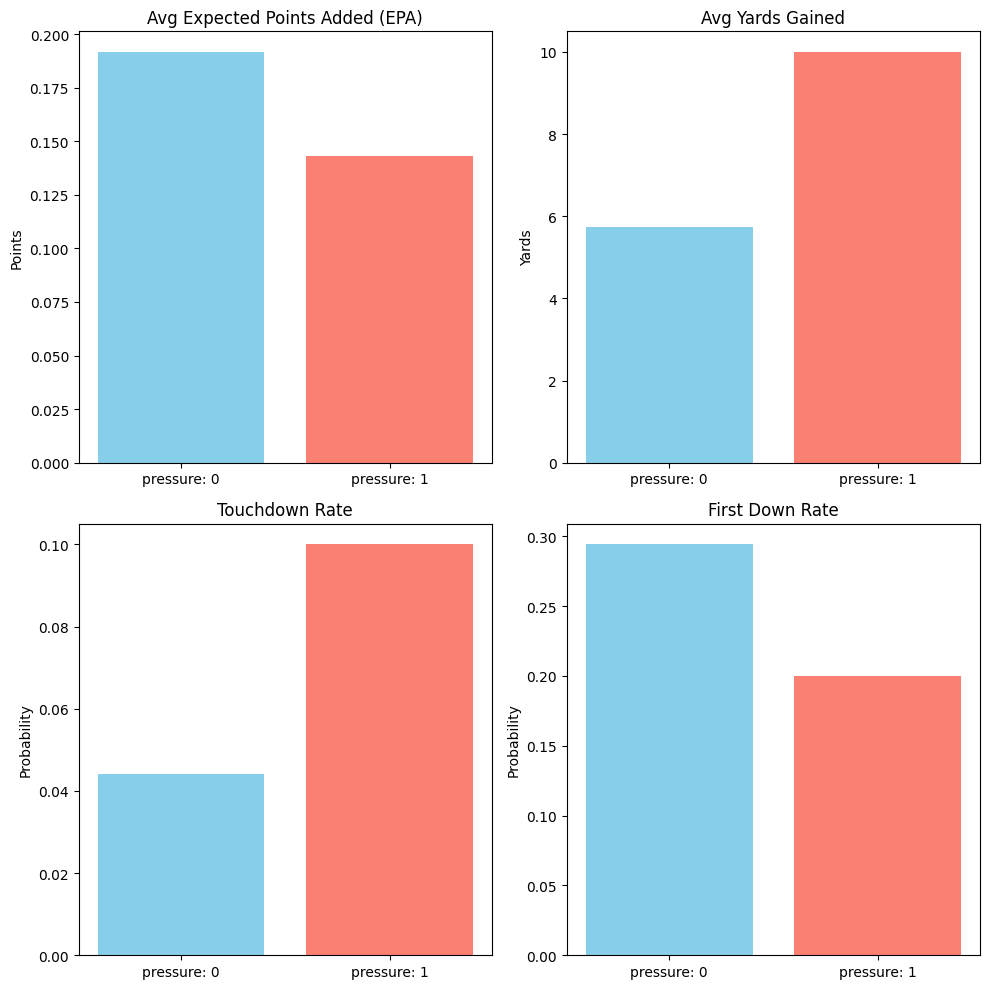

In [82]:
chosen_metric = 'pressure'
chosen_team = "ORUN"

# 1. Filter for the specific offense first
# We use .copy() to avoid SettingWithCopyWarnings later
offense_df = whiteouts[(whiteouts['offense'] == chosen_team) & (whiteouts['play_type'].isin(['dropback', 'designed run']))].copy()
offense_df['first_down_gained'] = offense_df['first_down_gained'].fillna(0)

# 2. Create the 'Draw' DataFrame (draw == 1)
draw_plays_df = offense_df[offense_df['trick_look'] == 1].copy()

# 3. Create the 'Non-Draw' DataFrame (draw == 0)
no_draw_plays_df = offense_df[offense_df['trick_look'] == 0].copy()

# Optional: Narrow down to key performance metrics for easier analysis
metrics_cols = [
    'season', 'week', 'down', 'distance', 'draw', 'gain_loss', 'yards_to_goal_line', 'trick_play', 'screen', 'unbalanced',
    'expected_points_added', 'success', 'touchdown', 'first_down_gained',
    'play_action', 'time_to_throw', 'yards_after_contact', 'run_pass'
]

draw_metrics = draw_plays_df[metrics_cols]
no_draw_metrics = no_draw_plays_df[metrics_cols]

# 1. Create the comparison DataFrame
comparison = offense_df.groupby(chosen_metric)[['expected_points_added', 'gain_loss', 'touchdown', 'first_down_gained']].agg(['mean', 'count'])
print(comparison)

# 2. Flatten the MultiIndex columns so we can access them easily
# This changes ('expected_points_added', 'mean') into 'epa_mean', etc.
comparison.columns = ['epa_mean', 'epa_count', 'yards_mean', 'yards_count', 
                     'td_mean', 'td_count', 'fd_mean', 'fd_count']

# 3. Reset index so 'screen' becomes a column for the X-axis labels
plot_df = comparison.reset_index()

# Set up the figure and axes (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Custom labels for the X-axis (e.g., "Screen: 0", "Screen: 1")
x_labels = [f"{chosen_metric}: {val}" for val in plot_df[chosen_metric]]
colors = ['skyblue', 'salmon']

# Plot 1: Avg EPA
axes[0, 0].bar(x_labels, plot_df['epa_mean'], color=colors)
axes[0, 0].set_title('Avg Expected Points Added (EPA)')
axes[0, 0].set_ylabel('Points')

# Plot 2: Avg Yards Gained
axes[0, 1].bar(x_labels, plot_df['yards_mean'], color=colors)
axes[0, 1].set_title('Avg Yards Gained')
axes[0, 1].set_ylabel('Yards')

# Plot 3: Touchdown Rate
axes[1, 0].bar(x_labels, plot_df['td_mean'], color=colors)
axes[1, 0].set_title('Touchdown Rate')
axes[1, 0].set_ylabel('Probability')

# Plot 4: First Down Rate
axes[1, 1].bar(x_labels, plot_df['fd_mean'], color=colors)
axes[1, 1].set_title('First Down Rate')
axes[1, 1].set_ylabel('Probability')

plt.tight_layout()
plt.show()

In [43]:
whiteouts['play_type'].unique()

array(['kickoff', 'designed run', 'dropback', 'no play', 'punt',
       'field goal', 'extra point'], dtype=object)